# 🧠 Classification with Logistic Regression

---

# 1. Executive Summary

This lecture introduces **classification problems** and **logistic regression** - one of the most widely used learning algorithms in industry. Unlike linear regression which predicts continuous values, classification problems involve predicting discrete categories (like spam/not spam, malignant/benign).

The key insight is that linear regression fails for classification because it's sensitive to outliers and can produce predictions outside the [0,1] range. Logistic regression solves this by using the **sigmoid function** to squash outputs between 0 and 1, which can be interpreted as probabilities.

By the end of this module, you'll understand: why linear regression fails for classification, how logistic regression works mathematically, the concept of decision boundaries, and how to interpret logistic regression outputs as probabilities.

---

# 2. Key Concepts & Glossary

| **Term** | **Definition** |
|----------|----------------|
| **Binary Classification** | Problems where output y can only take two values (0/1, false/true, no/yes) |
| **Negative Class** | The class labeled as 0 (e.g., "not spam", "benign") |
| **Positive Class** | The class labeled as 1 (e.g., "spam", "malignant") |
| **Sigmoid Function** | \( $g(z) = \frac{1}{1 + e^{-z}}$ \) - S-shaped function that outputs values between 0 and 1 |
| **Logistic Function** | Another name for the sigmoid function |
| **Decision Boundary** | The line or curve separating where model predicts 0 vs 1 |
| **z (linear combination)** | \( $z = \vec{w} \cdot \vec{x} + b$ \) - the input to sigmoid |
| **Probability Output** | \( $f_{\vec{w},b}(\vec{x}) = P(y=1 \mid \vec{x}; \vec{w},b)$ \) - interpreted as probability that y=1 |
| **Threshold** | Typically 0.5: if \( $f(x) \geq 0.5$ \), predict 1; else predict 0 |
| **Polynomial Features** | Using higher-order terms (\( $x^2, x_1x_2, etc.$ \)) to create non-linear decision boundaries |

---

# 3. Important Data Points

## Key Formulas

| **Formula** | **Description** | **Terms** |
|-------------|-----------------|-----------|
| \( $z = \vec{w} \cdot \vec{x} + b$ \) | Linear combination | \( $\vec{w}$ \): weight vector, \( $\vec{x}$ \): input features, \( $b$ \): bias |
| \( $g(z) = \frac{1}{1 + e^{-z}}$ \) | Sigmoid function | \( $e$ \): Euler's number (~2.718), \( $z$ \): linear combination |
| \( $f_{\vec{w},b}(\vec{x}) = g(\vec{w} \cdot \vec{x} + b)$ \) | Logistic regression model | Output is probability between 0 and 1 |
| \( $P(y=1 \mid \vec{x}; \vec{w},b) + P(y=0 \mid \vec{x}; \vec{w},b) = 1$ \) | Probability sum | Probabilities for both classes sum to 1 |

## Key Properties of Sigmoid Function

| **Condition** | **Result** |
|---------------|------------|
| \( $z \to \infty \) | \( g(z) \to 1$ \) |
| \( $z = 0 \) | \( g(z) = 0.5$ \) |
| \( $z \to -\infty \) | \( g(z) \to 0$ \) |

---

# 4. Core Concepts

## 4.1 Why Linear Regression Fails for Classification

Linear regression is designed for continuous outputs, not discrete categories. When applied to classification:

1. **Outliers dramatically shift the decision boundary** - Adding one extreme example can completely change where the model draws the line
2. **Predictions outside [0,1]** - Linear regression can output values <0 or >1, which don't make sense for probabilities
3. **Threshold sensitivity** - The 0.5 threshold is arbitrary and sensitive to data distribution

Let's visualize this problem:

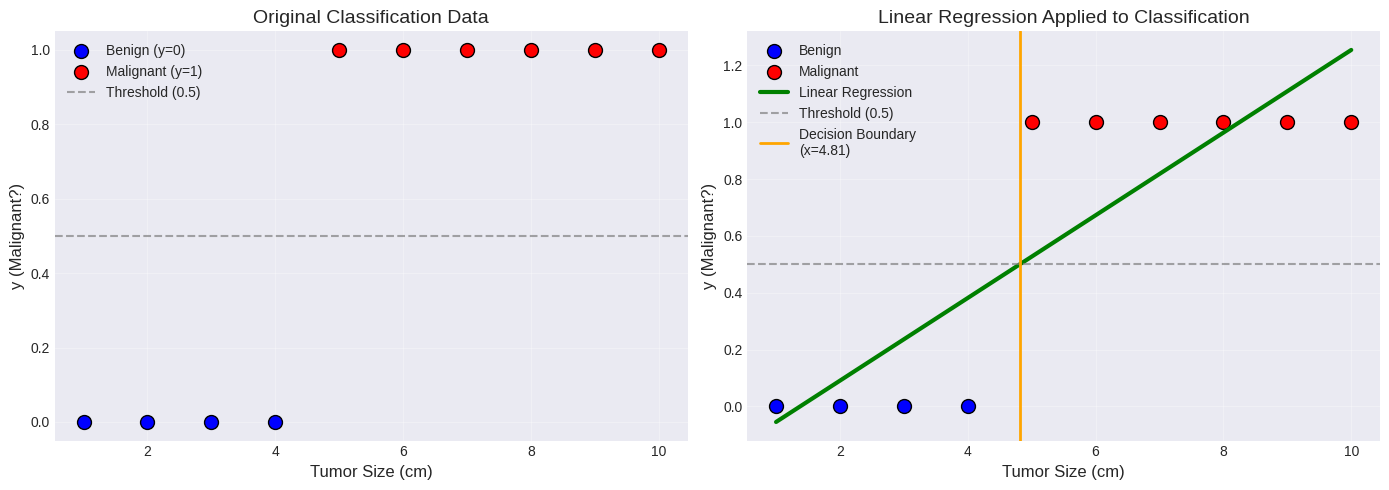

Linear regression predictions range: [-0.055, 1.255]
Notice predictions outside [0,1] - not valid probabilities!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')

# Generate data
np.random.seed(42)
tumor_sizes = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
malignant = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

# Fit linear regression
lr = LinearRegression()
lr.fit(tumor_sizes, malignant)
predictions = lr.predict(tumor_sizes)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original data
axes[0].scatter(tumor_sizes[malignant==0], malignant[malignant==0],
                color='blue', s=100, label='Benign (y=0)', edgecolors='black')
axes[0].scatter(tumor_sizes[malignant==1], malignant[malignant==1],
                color='red', s=100, label='Malignant (y=1)', edgecolors='black')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold (0.5)')
axes[0].set_xlabel('Tumor Size (cm)', fontsize=12)
axes[0].set_ylabel('y (Malignant?)', fontsize=12)
axes[0].set_title('Original Classification Data', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Linear regression fit
axes[1].scatter(tumor_sizes[malignant==0], malignant[malignant==0],
                color='blue', s=100, label='Benign', edgecolors='black')
axes[1].scatter(tumor_sizes[malignant==1], malignant[malignant==1],
                color='red', s=100, label='Malignant', edgecolors='black')
axes[1].plot(tumor_sizes, predictions, color='green', linewidth=3, label='Linear Regression')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold (0.5)')

# Find decision boundary
decision_x = (0.5 - lr.intercept_) / lr.coef_[0]
axes[1].axvline(x=decision_x, color='orange', linestyle='-', linewidth=2,
                label=f'Decision Boundary\n(x={decision_x:.2f})')

axes[1].set_xlabel('Tumor Size (cm)', fontsize=12)
axes[1].set_ylabel('y (Malignant?)', fontsize=12)
axes[1].set_title('Linear Regression Applied to Classification', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Linear regression predictions range: [{predictions.min():.3f}, {predictions.max():.3f}]")
print(f"Notice predictions outside [0,1] - not valid probabilities!")

## 4.2 The Sigmoid Function

The sigmoid (logistic) function is the secret sauce that makes logistic regression work. It maps any real number to a value between 0 and 1, making it perfect for probability estimation.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


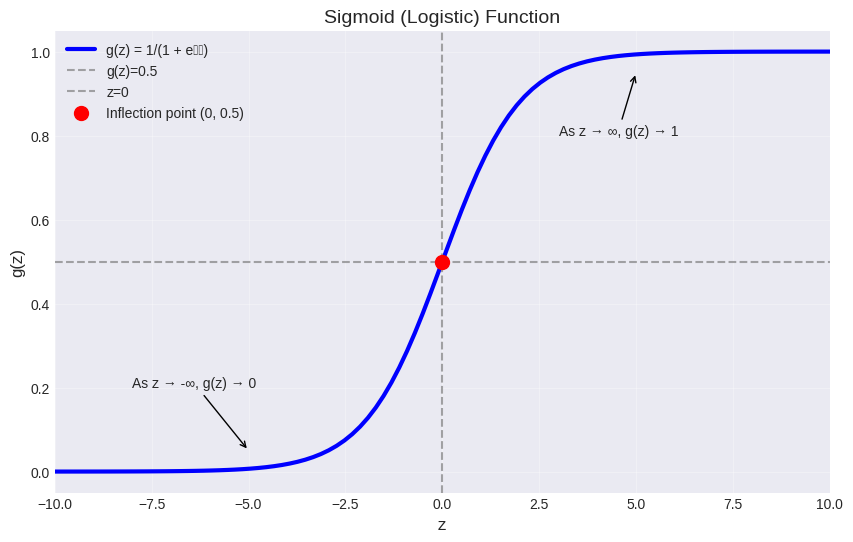

g(-∞) → 0
g(-10) = 0.000045
g(-5) = 0.006693
g(0) = 0.500000
g(5) = 0.993307
g(10) = 0.999955
g(∞) → 1


In [2]:
# Visualize the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Create values
z = np.linspace(-10, 10, 100)
g_z = sigmoid(z)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(z, g_z, 'b-', linewidth=3, label='g(z) = 1/(1 + e⁻ᶻ)')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='g(z)=0.5')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='z=0')
plt.scatter([0], [0.5], color='red', s=100, zorder=5, label='Inflection point (0, 0.5)')

# Add annotations
plt.annotate('As z → ∞, g(z) → 1', xy=(5, 0.95), xytext=(3, 0.8),
             arrowprops=dict(arrowstyle='->', color='black'))
plt.annotate('As z → -∞, g(z) → 0', xy=(-5, 0.05), xytext=(-8, 0.2),
             arrowprops=dict(arrowstyle='->', color='black'))

plt.xlabel('z', fontsize=12)
plt.ylabel('g(z)', fontsize=12)
plt.title('Sigmoid (Logistic) Function', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-10, 10)
plt.ylim(-0.05, 1.05)
plt.show()

# Show key values
print(f"g(-∞) → 0")
print(f"g(-10) = {sigmoid(-10):.6f}")
print(f"g(-5) = {sigmoid(-5):.6f}")
print(f"g(0) = {sigmoid(0):.6f}")
print(f"g(5) = {sigmoid(5):.6f}")
print(f"g(10) = {sigmoid(10):.6f}")
print(f"g(∞) → 1")


## 4.3 Logistic Regression Model

Logistic regression combines linear regression with the sigmoid function:

1. **Step 1**: Compute linear combination \( $z = \vec{w} \cdot \vec{x} + b$ \)
2. **Step 2**: Pass z through sigmoid: \( $f(\vec{x}) = g(z) = \frac{1}{1 + e^{-z}}$ \)

The output is interpreted as: \( $f(\vec{x}) = P(y=1 \mid \vec{x}; \vec{w}, b) $\)


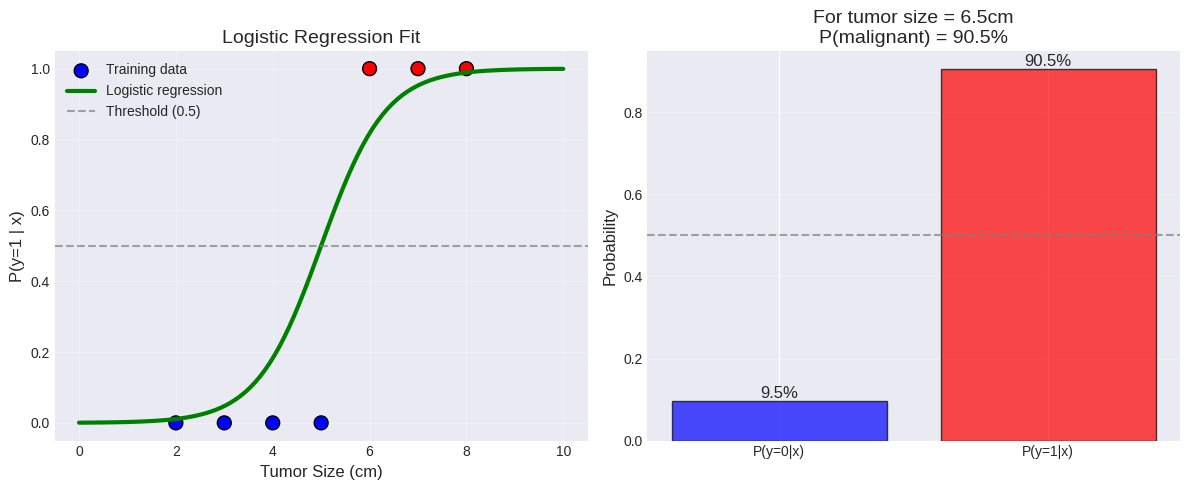

Interpretation: f(x) = P(y=1 | x; w, b)
For tumor size 6.5cm, probability of malignancy = 90.5%
Probability of benign = 9.5%
Check: 90.5% + 9.5% = 100%


In [3]:
# Demonstrate logistic regression for tumor classification
def logistic_regression(x, w, b):
    z = w * x + b
    return sigmoid(z)

# Parameters (let's choose reasonable values)
w = 1.5  # weight (slope)
b = -7.5  # bias (intercept)

# Generate tumor sizes
tumor_sizes = np.linspace(0, 10, 100)
probabilities = logistic_regression(tumor_sizes, w, b)

# Plot
plt.figure(figsize=(12, 5))

# Plot 1: Logistic regression curve
plt.subplot(1, 2, 1)
plt.scatter([2, 3, 4, 5, 6, 7, 8], [0, 0, 0, 0, 1, 1, 1],
            color=['blue', 'blue', 'blue', 'blue', 'red', 'red', 'red'],
            s=100, edgecolors='black', label='Training data')
plt.plot(tumor_sizes, probabilities, 'g-', linewidth=3, label='Logistic regression')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold (0.5)')
plt.xlabel('Tumor Size (cm)', fontsize=12)
plt.ylabel('P(y=1 | x)', fontsize=12)
plt.title('Logistic Regression Fit', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Probability interpretation
plt.subplot(1, 2, 2)
example_size = 6.5
prob = logistic_regression(example_size, w, b)

# Create bar chart
bars = plt.bar(['P(y=0|x)', 'P(y=1|x)'], [1-prob, prob],
               color=['blue', 'red'], alpha=0.7, edgecolor='black')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
plt.ylabel('Probability', fontsize=12)
plt.title(f'For tumor size = {example_size}cm\nP(malignant) = {prob:.1%}', fontsize=14)

# Add value labels
for bar, val in zip(bars, [1-prob, prob]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1%}', ha='center', va='bottom', fontsize=12)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Interpretation: f(x) = P(y=1 | x; w, b)")
print(f"For tumor size {example_size}cm, probability of malignancy = {prob:.1%}")
print(f"Probability of benign = {1-prob:.1%}")
print(f"Check: {prob:.1%} + {1-prob:.1%} = 100%")

## 4.4 Decision Boundaries

The decision boundary is where the model is exactly neutral (f(x) = 0.5). This happens when z = 0, i.e., \( $\vec{w} \cdot \vec{x} + b = 0$ \).

### Linear Decision Boundary Example

/tmp/ipykernel_382/1548490774.py:44: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_382/1548490774.py:44: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


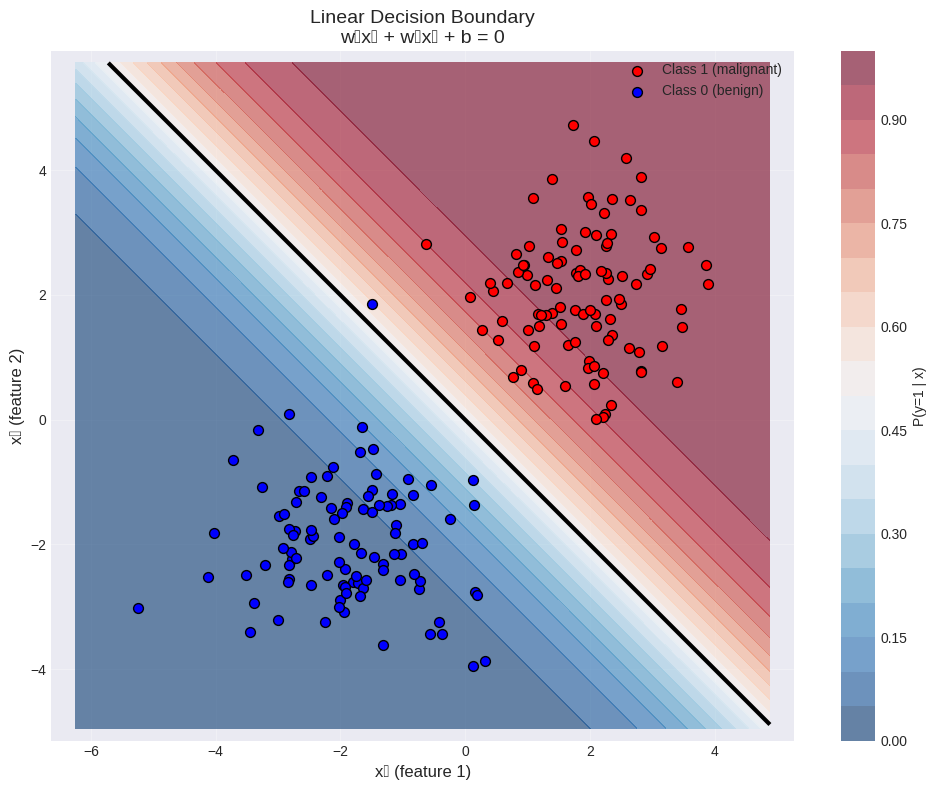

Decision boundary equation: 1.0·x₁ + 1.0·x₂ + 0.0 = 0
Or simply: x₁ + x₂ = 0


In [4]:
# Create synthetic 2D classification data
np.random.seed(42)
n_samples = 100

# Generate two clusters
X1 = np.random.randn(n_samples, 2) + np.array([2, 2])  # Class 1
X2 = np.random.randn(n_samples, 2) + np.array([-2, -2])  # Class 0
X = np.vstack([X1, X2])
y = np.hstack([np.ones(n_samples), np.zeros(n_samples)])

# Define logistic regression parameters (manually chosen for demonstration)
w = np.array([1.0, 1.0])
b = 0.0

# Create mesh for decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Compute z values
z = w[0] * xx + w[1] * yy + b

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, sigmoid(z), levels=20, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1 | x)')

# Plot decision boundary (z=0)
plt.contour(xx, yy, z, levels=[0], colors='black', linewidths=3, linestyles='-')

# Plot data points
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', s=50, label='Class 1 (malignant)',
            edgecolors='black', linewidth=1)
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', s=50, label='Class 0 (benign)',
            edgecolors='black', linewidth=1)

plt.xlabel('x₁ (feature 1)', fontsize=12)
plt.ylabel('x₂ (feature 2)', fontsize=12)
plt.title('Linear Decision Boundary\nw₁x₁ + w₂x₂ + b = 0', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Decision boundary equation: {w[0]}·x₁ + {w[1]}·x₂ + {b} = 0")
print(f"Or simply: x₁ + x₂ = 0")

### Non-linear Decision Boundary with Polynomial Features


/tmp/ipykernel_382/2606142187.py:49: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_382/2606142187.py:49: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


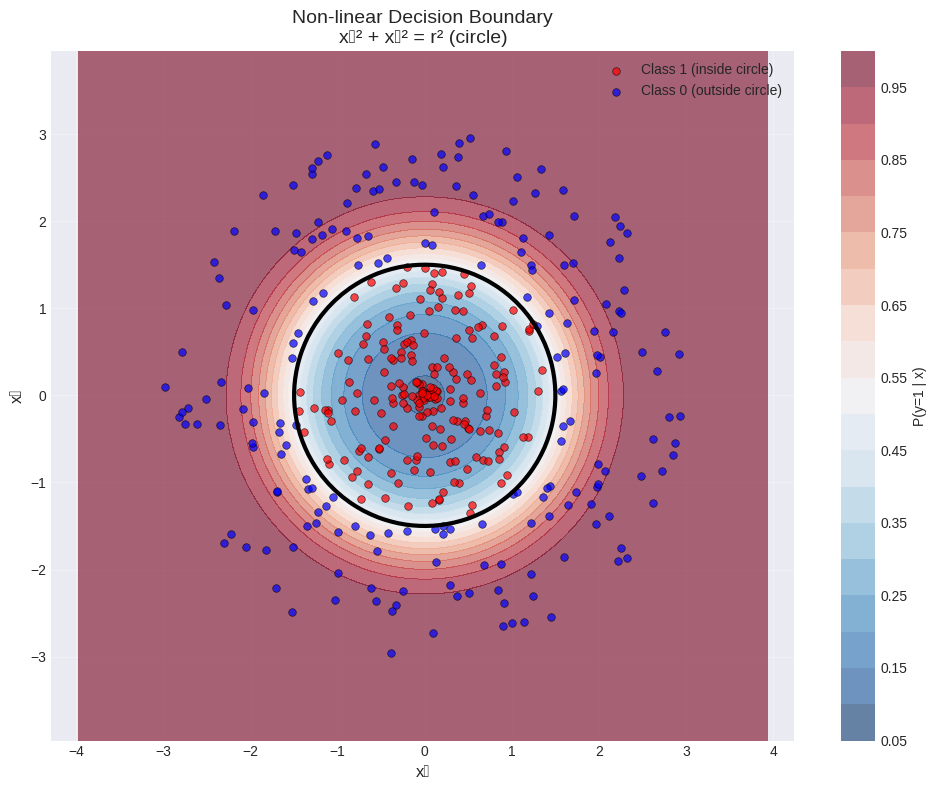

Decision boundary equation: x₁² + x₂² = 2.25
Inside circle (x₁² + x₂² < 2.25): predict class 1
Outside circle (x₁² + x₂² > 2.25): predict class 0


In [5]:
# Create concentric circle data
np.random.seed(42)
n_samples = 200

# Generate points in a circle
theta = np.random.uniform(0, 2*np.pi, n_samples)
r_class1 = np.random.uniform(0, 1.5, n_samples)  # Inside circle (class 1)
r_class0 = np.random.uniform(1.5, 3, n_samples)   # Outside circle (class 0)

X1 = np.column_stack([r_class1 * np.cos(theta), r_class1 * np.sin(theta)])
X0 = np.column_stack([r_class0 * np.cos(theta[:len(r_class0)]),
                      r_class0 * np.sin(theta[:len(r_class0)])])

X = np.vstack([X1, X0])
y = np.hstack([np.ones(len(X1)), np.zeros(len(X0))])

# Define polynomial decision boundary: x₁² + x₂² - r² = 0
r_squared = 2.25  # 1.5²

# Create mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Compute z using polynomial features: z = x₁² + x₂² - r²
z_poly = xx**2 + yy**2 - r_squared

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, sigmoid(z_poly), levels=20, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1 | x)')

# Plot decision boundary (z=0 circle)
plt.contour(xx, yy, z_poly, levels=[0], colors='black', linewidths=3, linestyles='-')

# Plot data points
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', s=30, label='Class 1 (inside circle)',
            alpha=0.7, edgecolors='black', linewidth=0.5)
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', s=30, label='Class 0 (outside circle)',
            alpha=0.7, edgecolors='black', linewidth=0.5)

plt.xlabel('x₁', fontsize=12)
plt.ylabel('x₂', fontsize=12)
plt.title('Non-linear Decision Boundary\nx₁² + x₂² = r² (circle)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Decision boundary equation: x₁² + x₂² = {r_squared:.2f}")
print(f"Inside circle (x₁² + x₂² < {r_squared:.2f}): predict class 1")
print(f"Outside circle (x₁² + x₂² > {r_squared:.2f}): predict class 0")

# 5. Visualizations

## 5.1 Sigmoid Function Family

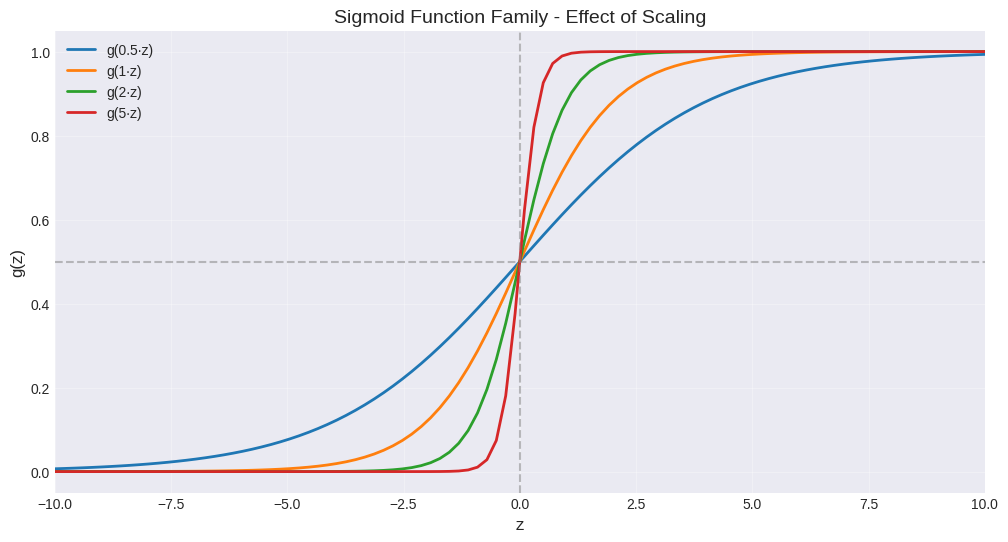

Larger scaling (a) makes the transition from 0 to 1 sharper
Smaller scaling makes the transition more gradual


In [6]:
# Show different sigmoid curves with different parameters
z = np.linspace(-10, 10, 100)

plt.figure(figsize=(12, 6))

# Vary the slope
for a in [0.5, 1, 2, 5]:
    g_z = sigmoid(a * z)
    plt.plot(z, g_z, linewidth=2, label=f'g({a}·z)')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z', fontsize=12)
plt.ylabel('g(z)', fontsize=12)
plt.title('Sigmoid Function Family - Effect of Scaling', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-10, 10)
plt.ylim(-0.05, 1.05)
plt.show()

print("Larger scaling (a) makes the transition from 0 to 1 sharper")
print("Smaller scaling makes the transition more gradual")

## 5.2 Probability Calibration

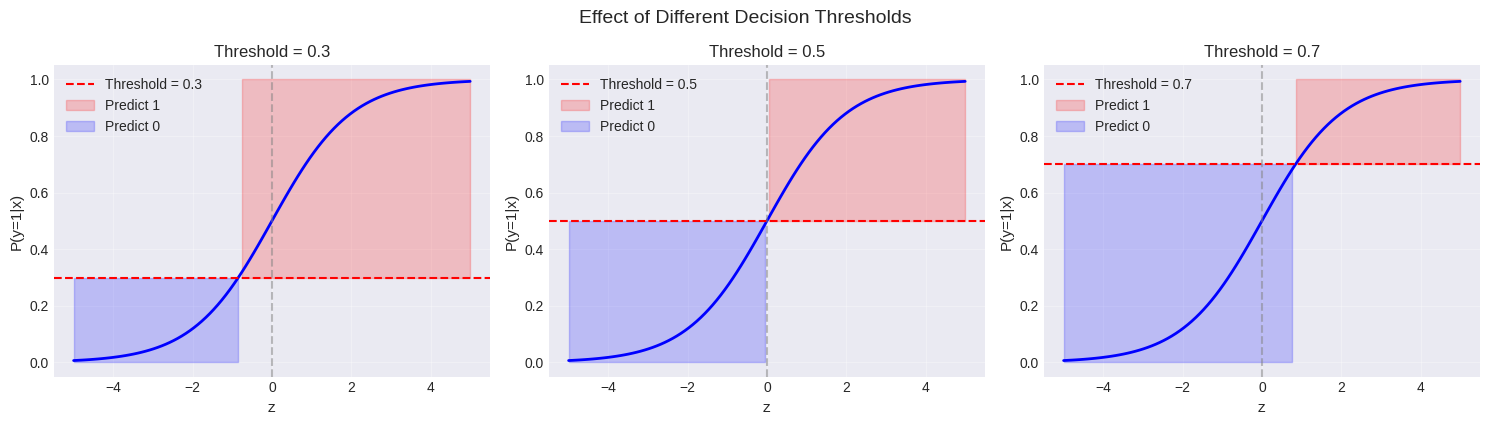

Lower threshold: more conservative (more likely to predict 1)
Higher threshold: more aggressive (less likely to predict 1)
Default threshold of 0.5 balances sensitivity and specificity


In [7]:
# Show probability calibration for different thresholds
thresholds = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, threshold in enumerate(thresholds):
    # Create data
    z_vals = np.linspace(-5, 5, 100)
    probs = sigmoid(z_vals)

    axes[i].plot(z_vals, probs, 'b-', linewidth=2)
    axes[i].axhline(y=threshold, color='red', linestyle='--',
                    label=f'Threshold = {threshold}')
    axes[i].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].fill_between(z_vals, threshold, 1, where=(probs >= threshold),
                         color='red', alpha=0.2, label='Predict 1')
    axes[i].fill_between(z_vals, 0, threshold, where=(probs < threshold),
                         color='blue', alpha=0.2, label='Predict 0')

    axes[i].set_xlabel('z', fontsize=11)
    axes[i].set_ylabel('P(y=1|x)', fontsize=11)
    axes[i].set_title(f'Threshold = {threshold}', fontsize=12)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.suptitle('Effect of Different Decision Thresholds', fontsize=14, y=1.05)
plt.show()

print("Lower threshold: more conservative (more likely to predict 1)")
print("Higher threshold: more aggressive (less likely to predict 1)")
print("Default threshold of 0.5 balances sensitivity and specificity")

---

# 6. Code Examples

## Example 1: Complete Logistic Regression from Scratch


Iteration 0, Loss: 0.6931
Iteration 200, Loss: 0.0176
Iteration 400, Loss: 0.0103
Iteration 600, Loss: 0.0074
Iteration 800, Loss: 0.0059


/tmp/ipykernel_382/464472585.py:99: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_382/464472585.py:99: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


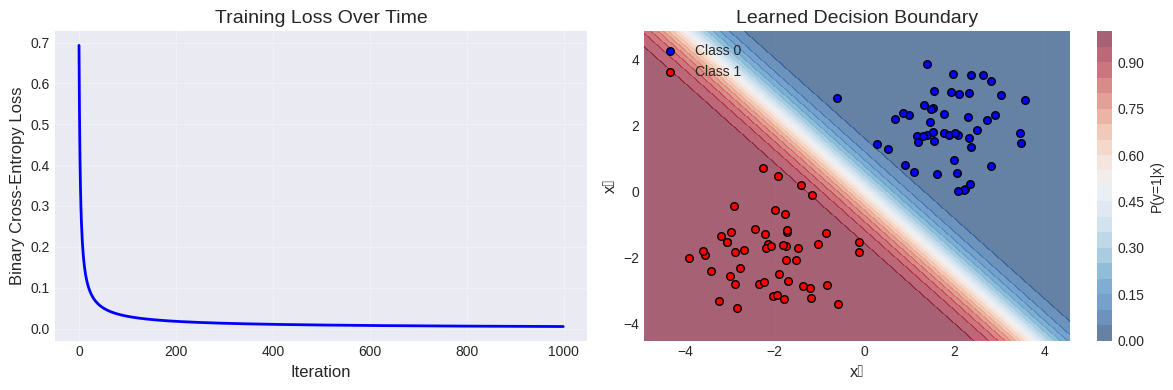

Final weights: [-2.24584561 -1.8532904 ]
Final bias: 0.0424
Final loss: 0.0049


In [8]:
class LogisticRegressionFromScratch:
    """Simple logistic regression implementation"""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        """Train using gradient descent"""
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient descent
        for i in range(self.n_iterations):
            # Forward pass
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)

            # Compute loss (binary cross-entropy)
            loss = -np.mean(y * np.log(y_pred + 1e-15) +
                           (1 - y) * np.log(1 - y_pred + 1e-15))
            self.loss_history.append(loss)

            # Backward pass (gradients)
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Print progress
            if i % 200 == 0:
                print(f"Iteration {i}, Loss: {loss:.4f}")

    def predict_proba(self, X):
        """Return probability estimates"""
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        """Return class predictions"""
        return (self.predict_proba(X) >= threshold).astype(int)

# Generate sample data
np.random.seed(42)
X_class0 = np.random.randn(50, 2) + np.array([2, 2])
X_class1 = np.random.randn(50, 2) + np.array([-2, -2])
X_train = np.vstack([X_class0, X_class1])
y_train = np.hstack([np.zeros(50), np.ones(50)])

# Train model
model = LogisticRegressionFromScratch(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)

# Plot loss curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model.loss_history, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.title('Training Loss Over Time', fontsize=14)
plt.grid(True, alpha=0.3)

# Plot decision boundary
plt.subplot(1, 2, 2)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1|x)')

plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
            color='blue', s=30, label='Class 0', edgecolors='black')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
            color='red', s=30, label='Class 1', edgecolors='black')

plt.xlabel('x₁', fontsize=12)
plt.ylabel('x₂', fontsize=12)
plt.title('Learned Decision Boundary', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final weights: {model.weights}")
print(f"Final bias: {model.bias:.4f}")
print(f"Final loss: {model.loss_history[-1]:.4f}")

## Example 2: Compare Linear Regression vs Logistic Regression


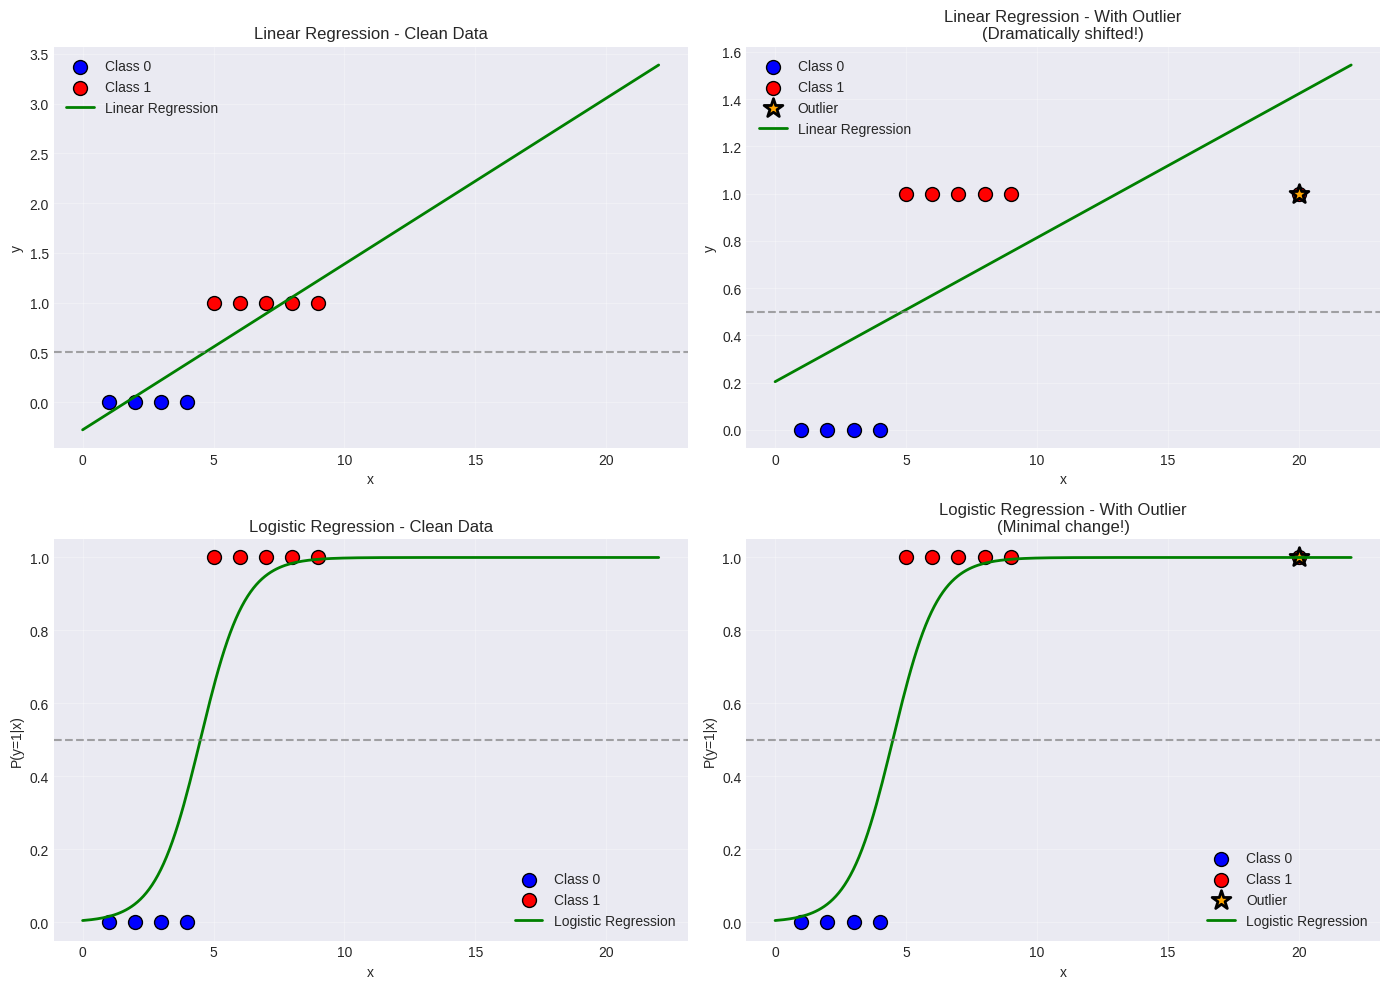

Key Insight: Logistic regression is robust to outliers because
the sigmoid function bounds outputs between 0 and 1, while
linear regression can be dramatically affected by extreme values.


In [9]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score

# Generate problematic data with outlier
np.random.seed(42)
X_clean = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
y_clean = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

X_outlier = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 20]).reshape(-1, 1)
y_outlier = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

# Fit models
lr_clean = LinearRegression().fit(X_clean, y_clean)
lr_outlier = LinearRegression().fit(X_outlier, y_outlier)
logreg_clean = LogisticRegression().fit(X_clean, y_clean)
logreg_outlier = LogisticRegression().fit(X_outlier, y_outlier)

# Create predictions for plotting
X_test = np.linspace(0, 22, 200).reshape(-1, 1)
lr_clean_pred = lr_clean.predict(X_test)
lr_outlier_pred = lr_outlier.predict(X_test)
logreg_clean_pred = logreg_clean.predict_proba(X_test)[:, 1]
logreg_outlier_pred = logreg_outlier.predict_proba(X_test)[:, 1]

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear regression - clean data
axes[0, 0].scatter(X_clean[y_clean==0], y_clean[y_clean==0],
                   color='blue', s=100, label='Class 0', edgecolors='black')
axes[0, 0].scatter(X_clean[y_clean==1], y_clean[y_clean==1],
                   color='red', s=100, label='Class 1', edgecolors='black')
axes[0, 0].plot(X_test, lr_clean_pred, 'g-', linewidth=2, label='Linear Regression')
axes[0, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Linear Regression - Clean Data', fontsize=12)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Linear regression - with outlier
axes[0, 1].scatter(X_outlier[y_outlier==0], y_outlier[y_outlier==0],
                   color='blue', s=100, label='Class 0', edgecolors='black')
axes[0, 1].scatter(X_outlier[y_outlier==1], y_outlier[y_outlier==1],
                   color='red', s=100, label='Class 1', edgecolors='black')
axes[0, 1].scatter([20], [1], color='orange', s=200, marker='*',
                   label='Outlier', edgecolors='black', linewidth=2)
axes[0, 1].plot(X_test, lr_outlier_pred, 'g-', linewidth=2, label='Linear Regression')
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
axes[0, 1].set_title('Linear Regression - With Outlier\n(Dramatically shifted!)', fontsize=12)
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Logistic regression - clean data
axes[1, 0].scatter(X_clean[y_clean==0], y_clean[y_clean==0],
                   color='blue', s=100, label='Class 0', edgecolors='black')
axes[1, 0].scatter(X_clean[y_clean==1], y_clean[y_clean==1],
                   color='red', s=100, label='Class 1', edgecolors='black')
axes[1, 0].plot(X_test, logreg_clean_pred, 'g-', linewidth=2, label='Logistic Regression')
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Logistic Regression - Clean Data', fontsize=12)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('P(y=1|x)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Logistic regression - with outlier
axes[1, 1].scatter(X_outlier[y_outlier==0], y_outlier[y_outlier==0],
                   color='blue', s=100, label='Class 0', edgecolors='black')
axes[1, 1].scatter(X_outlier[y_outlier==1], y_outlier[y_outlier==1],
                   color='red', s=100, label='Class 1', edgecolors='black')
axes[1, 1].scatter([20], [1], color='orange', s=200, marker='*',
                   label='Outlier', edgecolors='black', linewidth=2)
axes[1, 1].plot(X_test, logreg_outlier_pred, 'g-', linewidth=2, label='Logistic Regression')
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title('Logistic Regression - With Outlier\n(Minimal change!)', fontsize=12)
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('P(y=1|x)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Insight: Logistic regression is robust to outliers because")
print("the sigmoid function bounds outputs between 0 and 1, while")
print("linear regression can be dramatically affected by extreme values.")

---

# 7. Key Takeaways

1. **Linear regression fails for classification** because it's sensitive to outliers and produces predictions outside [0,1], which don't make sense as probabilities.

2. **Logistic regression uses the sigmoid function** \( $g(z) = \frac{1}{1+e^{-z}}$ \) to map any real number to a probability between 0 and 1.

3. **Model output = probability**: \( $f(\vec{x}) = P(y=1 \mid \vec{x}; \vec{w}, b) \), with \( P(y=0) = 1 - P(y=1)$ \).

4. **Decision boundary** is where \( $\vec{w} \cdot \vec{x} + b = 0$ \) $(f(x) = 0.5)$. For linear features, this is a line; with polynomial features, it can be any shape.

5. **Default threshold is 0.5**: Predict $y=1$ if $f(x) ≥ 0.5$, else predict $y=0$. This can be adjusted based on business needs (e.g., lower threshold for medical screening).

6. **Polynomial features** allow logistic regression to learn non-linear decision boundaries, making it much more flexible than its name suggests.

7. **Despite the name**, logistic regression is a classification algorithm, not regression. The name is historical.

---

# 8. Quick Revision

## Key Formulas

| **Formula** | **Meaning** |
|-------------|-------------|
| \( $z = \vec{w} \cdot \vec{x} + b$ \) | Linear combination of features |
| \( $g(z) = \frac{1}{1 + e^{-z}}$ \) | Sigmoid function squashes to [0,1] |
| \( $f(\vec{x}) = g(\vec{w} \cdot \vec{x} + b)$ \) | Complete logistic regression model |
| \( $f(\vec{x}) = P(y=1 \mid \vec{x}; \vec{w}, b)$ \) | Probability interpretation |
| \( $\vec{w} \cdot \vec{x} + b = 0$ \) | Decision boundary equation |

## Key Definitions

| **Term** | **Definition** |
|----------|----------------|
| **Binary Classification** | Problems with only two possible output values (0/1) |
| **Sigmoid Function** | S-shaped function that outputs values between 0 and 1 |
| **Decision Boundary** | The line/curve separating where model predicts 0 vs 1 |
| **Threshold** | Cutoff value (usually 0.5) for converting probabilities to classes |
| **Positive Class** | The class labeled as 1 (e.g., "malignant", "spam") |
| **Negative Class** | The class labeled as 0 (e.g., "benign", "not spam") |

## Sigmoid Properties

| **z value** | **g(z)** | **Interpretation** |
|-------------|----------|-------------------|
| z → ∞ | g(z) → 1 | Very confident class 1 |
| z = 0 | g(z) = 0.5 | Completely uncertain |
| z → -∞ | g(z) → 0 | Very confident class 0 |

## Decision Boundary Conditions

| **Condition** | **Prediction** |
|---------------|----------------|
| \( $\vec{w} \cdot \vec{x} + b \geq 0$ \) | Predict y = 1 |
| \( $\vec{w} \cdot \vec{x} + b < 0$ \) | Predict y = 0 |

---

